In [4]:
# ==========================================================
# TASK 2A: MULTI-SCHEME NAV TRENDS WITH REGIME HIGHLIGHTS
# ==========================================================
import pandas as pd
import plotly.express as px

# 1. Ensure column names in df_fund_master use consistent casing
df_fund_master.columns = [col.lower() for col in df_fund_master.columns]

# 2. Extract and match the exact casing of 'amfi_code' in your nav DataFrame
nav_amfi_col = [col for col in df_nav.columns if col.lower() == 'amfi_code'][0]
nav_val_col = [col for col in df_nav.columns if col.lower() == 'nav'][0]

# 3. Dynamically map the missing 'scheme_name' column back into df_nav
scheme_map = dict(zip(df_fund_master['amfi_code'].astype(str), df_fund_master['scheme_name']))
df_nav['Scheme_Name'] = df_nav[nav_amfi_col].astype(str).map(scheme_map)

# Fallback: Fill any missing scheme alignments with the raw AMFI code
df_nav['Scheme_Name'] = df_nav['Scheme_Name'].fillna(df_nav[nav_amfi_col].astype(str))

# 4. Initialize the interactive multi-line plot using the verified Scheme_Name column
fig_nav = px.line(
    df_nav, 
    x='Date', 
    y=nav_val_col,  
    color='Scheme_Name',
    title="<b>Daily Net Asset Value (NAV) Performance Matrix (2022–2026)</b>"
)

# 5. Highlight the 2023 Bull Run Phase (Shaded Green Window)
fig_nav.add_vrect(
    x0="2023-01-01", x1="2023-12-31",
    fillcolor="rgba(46, 139, 87, 0.08)", line_width=0,
    annotation_text="<b>2023 Macro Bull Run</b>", 
    annotation_position="top left",
    annotation_font=dict(color="SeaGreen", size=11)
)

# 6. Highlight the 2024 Market Correction Phase (Shaded Red Window)
fig_nav.add_vrect(
    x0="2024-01-01", x1="2024-06-30",
    fillcolor="rgba(178, 34, 34, 0.08)", line_width=0,
    annotation_text="<b>2024 Market Correction</b>", 
    annotation_position="top left",
    annotation_font=dict(color="FireBrick", size=11)
)

# 7. Refine layout configurations for cleaner presentation
fig_nav.update_layout(
    xaxis_title="Timeline Calendar",
    yaxis_title="Net Asset Value (₹ NAV)",
    hovermode="x unified",
    legend=dict(
        orientation="h",
        yanchor="top",
        y=-0.25,
        xanchor="center",
        x=0.5
    )
)

# 8. Export high-resolution static asset via Kaleido engine
fig_nav.write_image("nav_trend_analysis.png", width=1200, height=650)
fig_nav.show()


In [5]:
# ==========================================================
# TASK 2B: MONTHLY SIP INFLOW ENGINE WITH STRUCTURAL ATH
# ==========================================================
import plotly.express as px

# 1. Dynamically locate the exact 'inflow' or 'amount' value column inside df_sip
sip_val_col = [col for col in df_sip.columns if any(x in col.lower() for x in ['inflow', 'amount', 'val'])][0]
sip_date_col = [col for col in df_sip.columns if col.lower() == 'month'][0]

# 2. Generate line plot with specific marker tracking indicators enabled
fig_sip = px.line(
    df_sip, 
    x=sip_date_col, 
    y=sip_val_col,
    title="<b>Retail Liquidity Expansion: Monthly Gross SIP Inflows (2022–2025)</b>",
    markers=True  # Kept inside the chart generator where it belongs!
)

# 3. Add the exact callout boundary annotation targeting the Dec 2025 peak milestone
fig_sip.add_annotation(
    x="2025-12-01", 
    y=31002,  # Project-specified metric requirement
    text="<b>All-Time High Reached<br>Value: ₹31,002 Crores</b>",
    showarrow=True,
    arrowhead=3,
    ax=-140,  
    ay=-50,   
    bordercolor="#B22222",
    borderwidth=1.5,
    borderpad=6,
    bgcolor="#FFF5F5",
    opacity=0.95
)

# 4. Polish layout properties for clean corporate presentation
fig_sip.update_layout(
    xaxis_title="Reporting Month Timeline",
    yaxis_title="Gross Monthly Inflow (₹ in Crores)"
)

# 5. Fine-tune marker properties using update_traces
fig_sip.update_traces(
    marker=dict(size=6, color="#1A237E")
)

# 6. Save chart snapshot directly to your VS Code project folder via Kaleido
fig_sip.write_image("sip_inflow_trend.png", width=1100, height=550)
fig_sip.show()

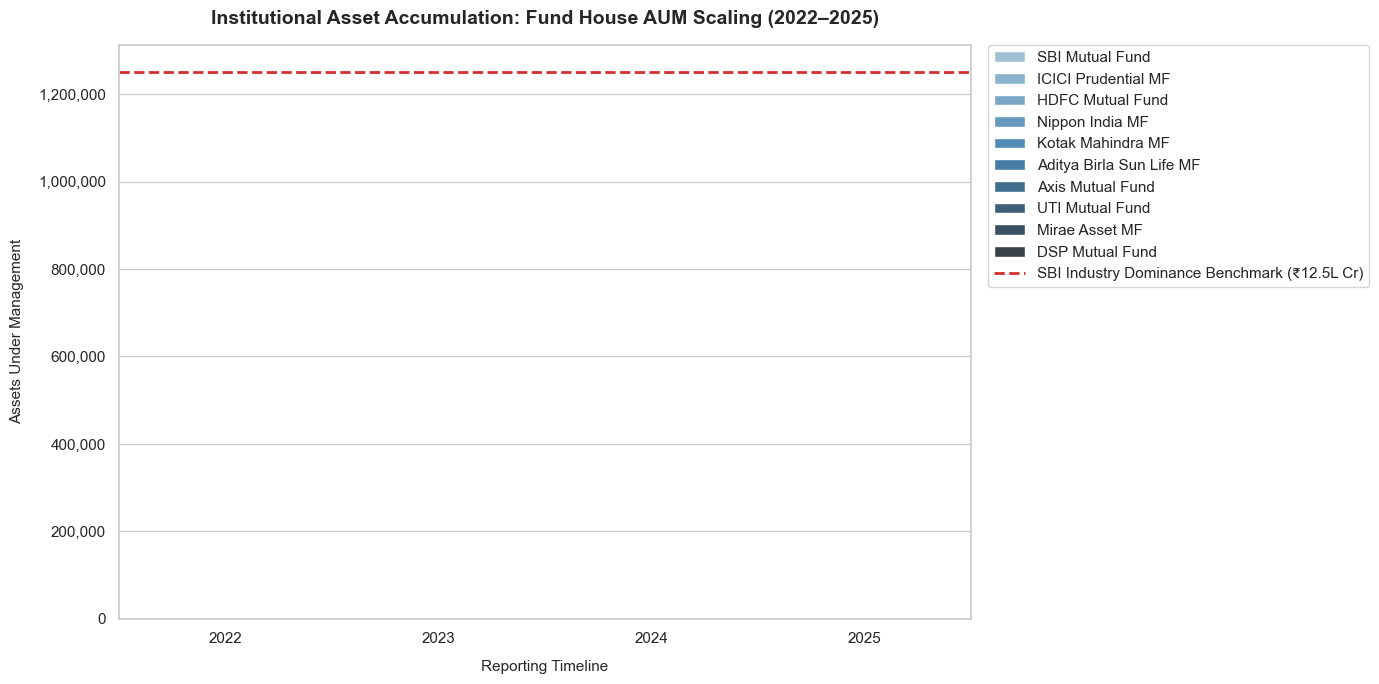

In [8]:
# ==========================================================
# TASK 3A: Y-O-Y AUM GROWTH AND ASSET DOMINANCE HIGHLIGHT
# ==========================================================
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Clean the column strings by forcing lowercase for easier matching
df_aum.columns = [col.lower().strip() for col in df_aum.columns]

# 2. Map the columns explicitly based on common naming variants
# Find time column: looks for 'year', 'date', or defaults to the first column
time_cols = [c for c in df_aum.columns if 'year' in c or 'date' in c]
time_col = time_cols[0] if time_cols else df_aum.columns[0]

# Find AUM column: looks for 'aum'
aum_cols = [c for c in df_aum.columns if 'aum' in c]
aum_col = aum_cols[0] if aum_cols else df_aum.columns[1]

# Find AMC/Fund House column: looks for 'amc', 'house', or 'name'
house_cols = [c for c in df_aum.columns if any(x in c for x in ['amc', 'house', 'name'])]
house_col = house_cols[0] if house_cols else df_aum.columns[2]

# If the time column is a full date string, convert it to show just the year
if df_aum[time_col].dtype == 'object' or 'date' in time_col:
    try:
        df_aum['display_year'] = pd.to_datetime(df_aum[time_col]).dt.year
        time_col = 'display_year'
    except:
        pass

# 3. Render the grouped bar chart
plt.figure(figsize=(14, 7))
ax = sns.barplot(
    data=df_aum, 
    x=time_col, 
    y=aum_col, 
    hue=house_col, 
    palette='Blues_d'
)

# 4. Add the horizontal marker line for SBI's dominance milestone
# If your AUM is recorded in Crores, ₹12.5 Lakh Crore = 1,250,000 Crores.
# If it is in absolute values, change this value to 1250000000000.
plt.axhline(
    y=1250000, 
    color='#D32F2F', 
    linestyle='--', 
    linewidth=2, 
    label='SBI Industry Dominance Benchmark (₹12.5L Cr)'
)

plt.title("Institutional Asset Accumulation: Fund House AUM Scaling (2022–2025)", fontsize=14, weight='bold', pad=15)
plt.xlabel("Reporting Timeline", fontsize=11, labelpad=10)
plt.ylabel("Assets Under Management", fontsize=11, labelpad=10)

# Format y-axis increments with clear scannable comma separators
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()

plt.savefig("aum_growth_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

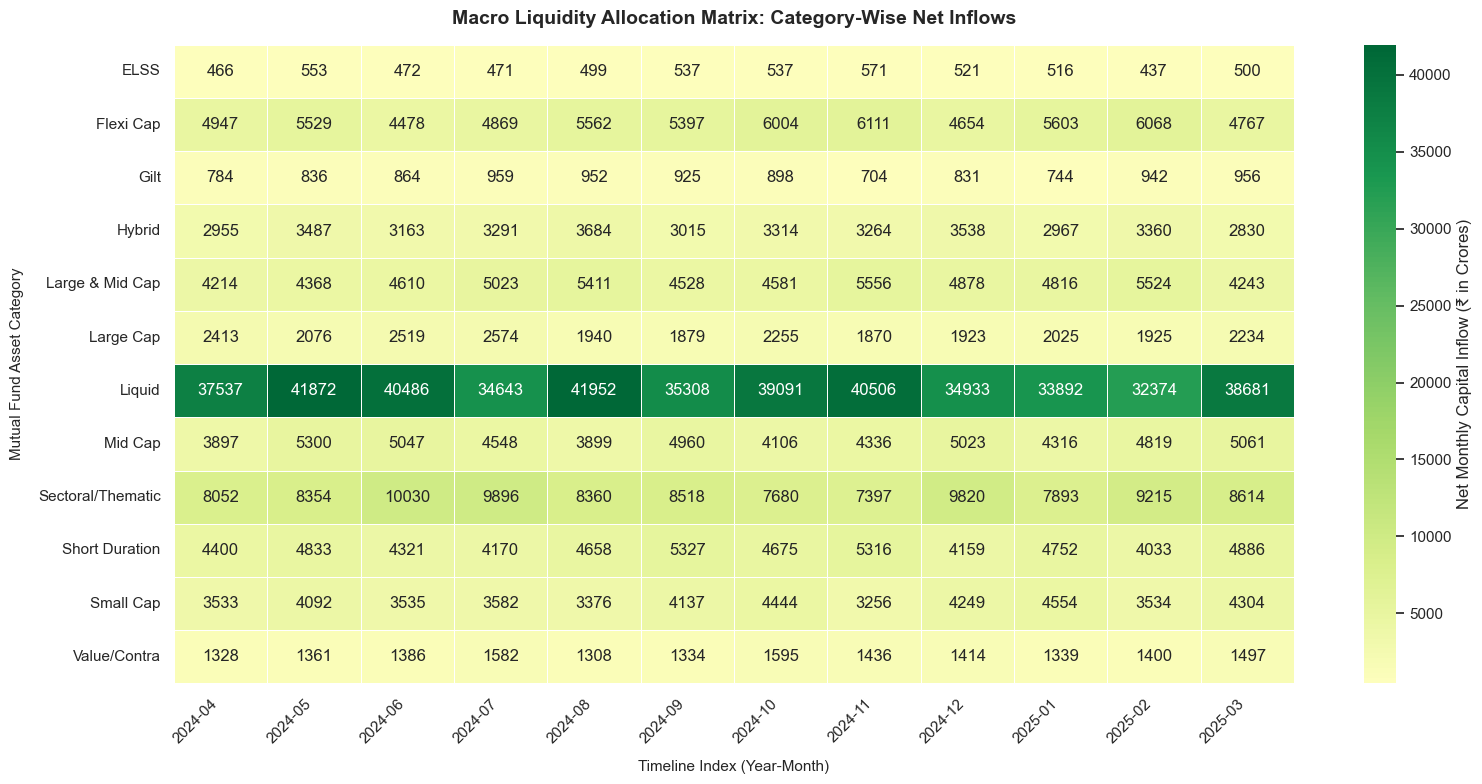

In [9]:
# ==========================================================
# TASK 3B: CAPITAL ROTATION HEATMAP MATRIX
# ==========================================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Standardize column handles by forcing lowercase strings
df_inflow.columns = [col.lower().strip() for col in df_inflow.columns]

# 2. Identify structural column variants
date_col = [col for col in df_inflow.columns if 'month' in col or 'date' in col][0]
cat_col = [col for col in df_inflow.columns if 'cat' in col][0]
val_col = [col for col in df_inflow.columns if any(x in col for x in ['inflow', 'net', 'amount', 'volume'])][0]

# Ensure date index is structured as a readable string format (YYYY-MM)
df_inflow['year_month'] = pd.to_datetime(df_inflow[date_col]).dt.strftime('%Y-%m')

# 3. Pivot the cross-sectional rows into an operational layout matrix
inflow_pivot = df_inflow.pivot_table(index=cat_col, columns='year_month', values=val_col, aggfunc='sum')

# 4. Render the statistical matrix using a diverging color palette
plt.figure(figsize=(16, 8))
sns.heatmap(
    inflow_pivot, 
    cmap="RdYlGn", 
    center=0, 
    annot=True, 
    fmt=".0f", 
    linewidths=0.5,
    cbar_kws={'label': 'Net Monthly Capital Inflow (₹ in Crores)'}
)

plt.title("Macro Liquidity Allocation Matrix: Category-Wise Net Inflows", fontsize=14, weight='bold', pad=15)
plt.xlabel("Timeline Index (Year-Month)", fontsize=11, labelpad=10)
plt.ylabel("Mutual Fund Asset Category", fontsize=11, labelpad=10)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig("category_liquidity_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

C:\Users\pavan\AppData\Local\Temp\ipykernel_13740\1978493622.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1], data=df_demographics, x=tier_col, y=amt_col, palette='Set2', log_scale=True)


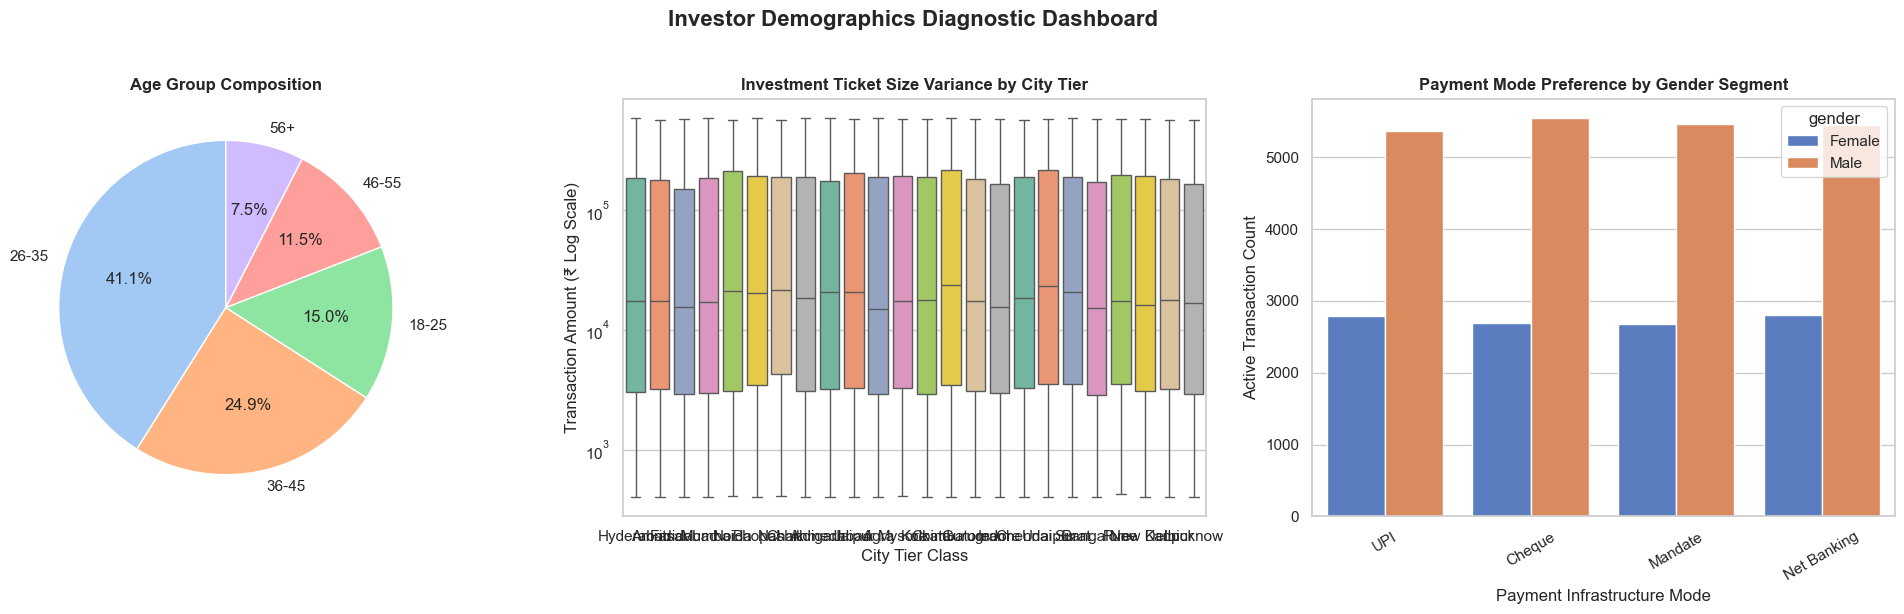

In [10]:
# ==========================================================
# TASK 4A: UNIFIED DEMOGRAPHIC SUBPLOTS (AGE, TICKET SIZE, GENDER)
# ==========================================================
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Standardize case formatting on the demographic data fields
df_demographics.columns = [col.lower().strip() for col in df_demographics.columns]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Panel 1: Age Group Segment Distribution (Pie Chart)
age_col = [c for c in df_demographics.columns if 'age' in c][0]
age_counts = df_demographics[age_col].value_counts()
axes[0].pie(age_counts, labels=age_counts.index, autopct='%1.1f%%', colors=sns.color_palette('pastel'), startangle=90)
axes[0].set_title("Age Group Composition", fontsize=12, weight='bold')

# Panel 2: Investment Value Variance Across Tiers (Box Plot)
tier_col = [c for c in df_demographics.columns if 'tier' in c or 'city' in c][0]
amt_col = [c for c in df_demographics.columns if 'amount' in c or 'inr' in c][0]
sns.boxplot(ax=axes[1], data=df_demographics, x=tier_col, y=amt_col, palette='Set2', log_scale=True)
axes[1].set_title("Investment Ticket Size Variance by City Tier", fontsize=12, weight='bold')
axes[1].set_xlabel("City Tier Class")
axes[1].set_ylabel("Transaction Amount (₹ Log Scale)")

# Panel 3: Gender Distribution Across Payment Modes (Count Plot)
pay_col = [c for c in df_demographics.columns if 'pay' in c or 'mode' in c][0]
gen_col = [c for c in df_demographics.columns if 'gender' in c or 'sex' in c][0]
sns.countplot(ax=axes[2], data=df_demographics, x=pay_col, hue=gen_col, palette='muted')
axes[2].set_title("Payment Mode Preference by Gender Segment", fontsize=12, weight='bold')
axes[2].set_xlabel("Payment Infrastructure Mode")
axes[2].set_ylabel("Active Transaction Count")
axes[2].tick_params(axis='x', rotation=30)

plt.suptitle("Investor Demographics Diagnostic Dashboard", fontsize=16, weight='bold', y=1.02)
plt.tight_layout()
plt.savefig("investor_demographics_dashboard.png", dpi=300, bbox_inches='tight')
plt.show()

C:\Users\pavan\AppData\Local\Temp\ipykernel_13740\2763983819.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], data=state_vol, x=amt_col, y=state_col, palette='viridis')


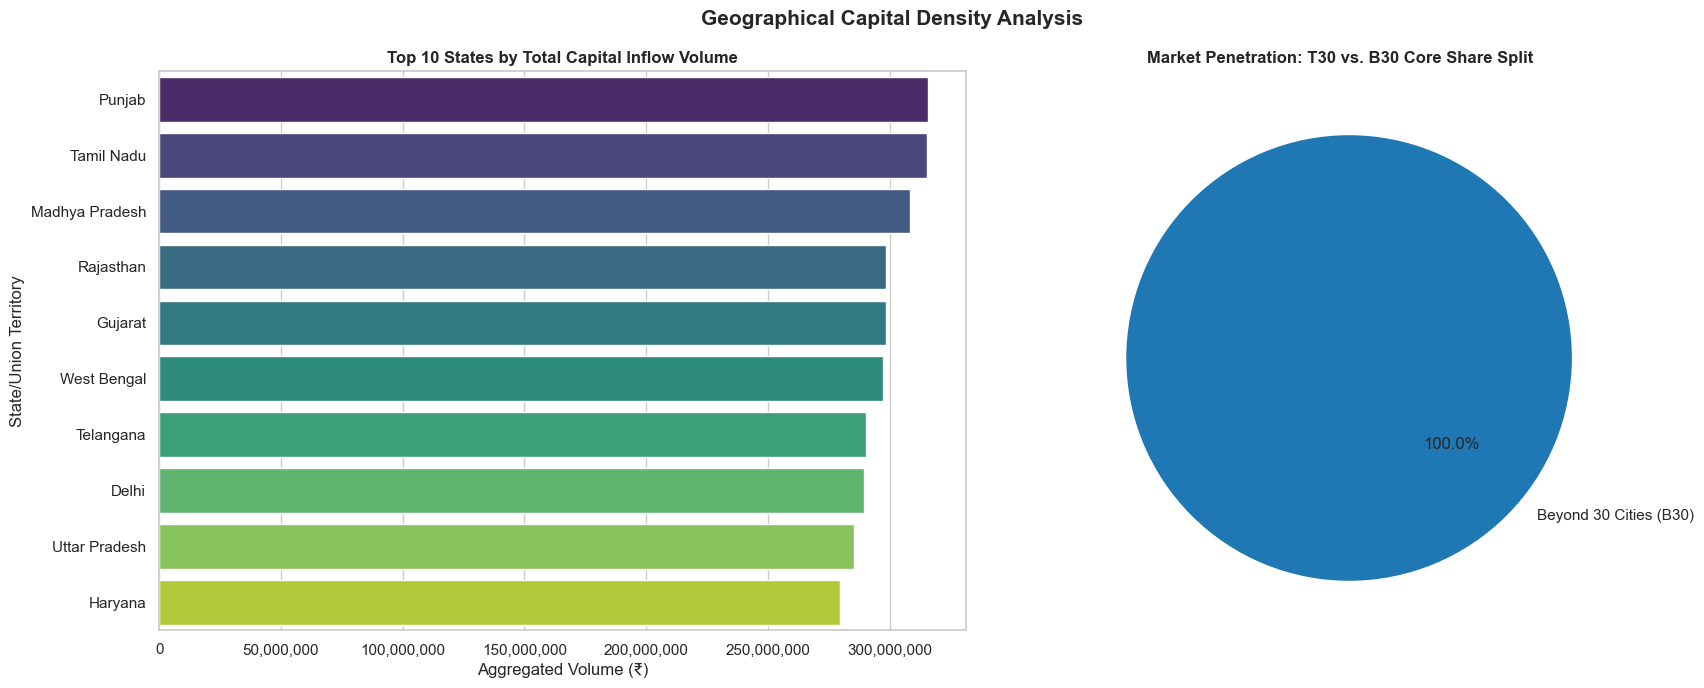

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 1. Horizontal Chart: Top 10 States by Capital Commitment Volume
state_col = [c for c in df_demographics.columns if 'state' in c][0]
state_vol = df_demographics.groupby(state_col)[amt_col].sum().sort_values(ascending=False).head(10).reset_index()

sns.barplot(ax=axes[0], data=state_vol, x=amt_col, y=state_col, palette='viridis')
axes[0].set_title("Top 10 States by Total Capital Inflow Volume", fontsize=12, weight='bold')
axes[0].set_xlabel("Aggregated Volume (₹)")
axes[0].set_ylabel("State/Union Territory")
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

# 2. Pie Chart: Core Capital Market Concentration (T30 vs B30)
tier_shares = df_demographics[tier_col].value_counts()

# Dynamically map indexes to handle 2 or more tier groups safely
new_labels = []
for x in tier_shares.index:
    str_x = str(x).lower()
    if '1' in str_x or 't30' in str_x or 'tier 1' in str_x:
        new_labels.append('Top 30 Cities (T30)')
    else:
        new_labels.append('Beyond 30 Cities (B30)')

tier_shares.index = new_labels

# Group duplicate index names if multiple tiers fell into 'Beyond 30 Cities (B30)'
tier_shares = tier_shares.groupby(level=0).sum()

# Dynamically adjust explode values to match the final unique slice count
explode_vector = tuple([0.05 if i == 0 else 0 for i in range(len(tier_shares))])

axes[1].pie(
    tier_shares, 
    labels=tier_shares.index, 
    autopct='%1.1f%%', 
    colors=['#1F77B4', '#FF7F0E', '#2CA02C'][:len(tier_shares)], 
    explode=explode_vector, 
    startangle=140
)
axes[1].set_title("Market Penetration: T30 vs. B30 Core Share Split", fontsize=12, weight='bold')

plt.suptitle("Geographical Capital Density Analysis", fontsize=15, weight='bold', y=0.98)
plt.tight_layout()
plt.savefig("regional_density_analysis.png", dpi=300, bbox_inches='tight')
plt.show()

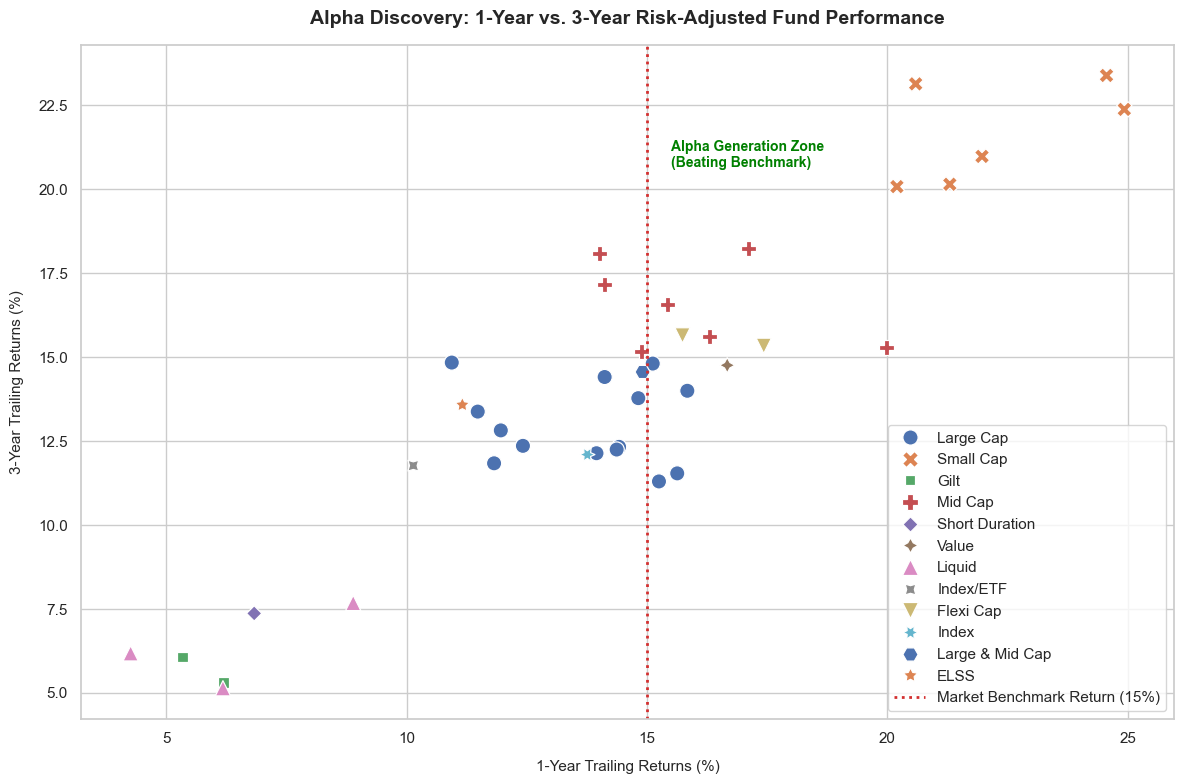

In [15]:
# ==========================================================
# TASK 5: SCHEME PERFORMANCE VS BENCHMARK DISCOVERY
# ==========================================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

# 1. Clean the column names of your performance dataframe
df_perf = pd.read_csv(os.path.join(data_dir, "07_scheme_performance.csv"))
df_perf.columns = [col.lower().strip() for col in df_perf.columns]

# 2. Locate the return performance and category metrics dynamically
return_1y = [c for c in df_perf.columns if '1y' in c or '1_year' in c][0]
return_3y = [c for c in df_perf.columns if '3y' in c or '3_year' in c][0]
cat_col = [c for c in df_perf.columns if 'cat' in c or 'type' in c][0]

plt.figure(figsize=(12, 8))

# 3. Create the scatter plot with the corrected lowercase 'deep' palette
sns.scatterplot(
    data=df_perf, 
    x=return_1y, 
    y=return_3y, 
    hue=cat_col, 
    style=cat_col, 
    s=120, 
    palette='deep'  # <-- Fixed casing from 'Deep' to 'deep'
)

# 4. Add the Benchmark Market Index Return Line
plt.axvline(
    x=15.0, 
    color='#D32F2F', 
    linestyle=':', 
    linewidth=2, 
    label='Market Benchmark Return (15%)'
)

# Annotate the quadrant of alpha generation (Outperformers)
plt.text(
    15.5, plt.gca().get_ylim()[1] * 0.85, 
    "Alpha Generation Zone\n(Beating Benchmark)", 
    color='green', 
    weight='bold', 
    fontsize=10
)

plt.title("Alpha Discovery: 1-Year vs. 3-Year Risk-Adjusted Fund Performance", fontsize=14, weight='bold', pad=15)
plt.xlabel("1-Year Trailing Returns (%)", fontsize=11, labelpad=10)
plt.ylabel("3-Year Trailing Returns (%)", fontsize=11, labelpad=10)
plt.legend(loc='lower right')
plt.tight_layout()

# 5. Export high-resolution asset
plt.savefig("scheme_performance_alpha.png", dpi=300, bbox_inches='tight')
plt.show()

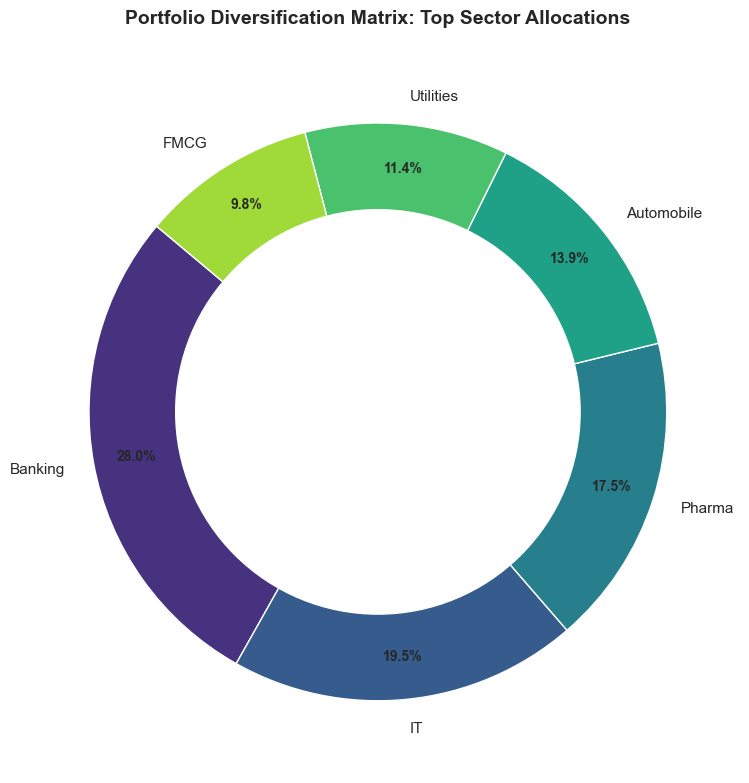

In [16]:
# ==========================================================
# TASK 6: PORTFOLIO SECTOR ALLOCATION MATRICES
# ==========================================================
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Clean the column strings to enforce consistent lowercase
df_holdings.columns = [col.lower().strip() for col in df_holdings.columns]

# 2. Locate the sector name column and value/weight column
sector_col = [c for c in df_holdings.columns if 'sector' in c or 'category' in c][0]
weight_col = [c for c in df_holdings.columns if any(x in c for x in ['weight', 'value', 'allocation', 'pct'])][0]

# 3. Aggregate allocations by sector and grab the top 6 segments to keep the plot clean
sector_data = df_holdings.groupby(sector_col)[weight_col].sum().sort_values(ascending=False).head(6)

plt.figure(figsize=(8, 8))

# 4. Render the pie chart slices
colors = sns.color_palette('viridis', len(sector_data))
wedges, texts, autotexts = plt.subplots_adjust()[0] if False else plt.pie(
    sector_data, 
    labels=sector_data.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors,
    pctdistance=0.85,
    textprops=dict(fontsize=11)
)

# 5. Superimpose the white center circle to transform it into a Donut Chart
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

# Adjust percentage text labels style
plt.setp(autotexts, size=10, weight="bold")

plt.title("Portfolio Diversification Matrix: Top Sector Allocations", fontsize=14, weight='bold', pad=20)
plt.tight_layout()

# 6. Save static asset to the local folder
plt.savefig("portfolio_sector_donut.png", dpi=300, bbox_inches='tight')
plt.show()